# Climate-Alpha: Quantitative ESG Trading Platform
## Complete Demonstration Notebook

This notebook demonstrates all components of the Climate-Alpha platform:
1. Data Collection
2. Feature Engineering
3. LSTM Price Prediction
4. Pairs Trading Strategy
5. Portfolio Optimization
6. Risk Management

In [1]:
# Import libraries
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import backend.data.features as features
import importlib
importlib.reload(features) 

from backend.data.collectors import DataCollector
from backend.data.features import FeatureEngineer
from backend.models.lstm_predictor import LSTMPredictor
from backend.strategies.pairs_trading import PairsTradingStrategy
from backend.risk.portfolio_opt import PortfolioOptimizer
from backend.risk.var_calculator import RiskCalculator
from backend.utils.metrics import PerformanceMetrics

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("All modules imported successfully")

All modules imported successfully


## 1. Data Collection

In [2]:
# Initialize data collector
collector = DataCollector()

# Download full universe
print("Downloading market data...")
data = collector.download_full_universe(
    start_date="2019-01-01",
    end_date="2025-12-31"
)

print(f"\nData shape: {data.shape}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")
print(f"\nTickers: {data.columns.get_level_values(0).unique().tolist()}")

2026-03-08 10:23:09 - climate_alpha - INFO - download_full_universe:249 - Downloading full universe: 32 tickers
2026-03-08 10:23:09 - climate_alpha - INFO - download_stock_data:54 - Downloading data for 32 tickers from 2019-01-01 to 2025-12-31
2026-03-08 10:23:09 - climate_alpha - INFO - download_stock_data:60 - Downloading ICLN...
2026-03-08 10:23:11 - climate_alpha - INFO - download_stock_data:71 - ICLN: 1759 rows
2026-03-08 10:23:11 - climate_alpha - INFO - download_stock_data:60 - Downloading TAN...
2026-03-08 10:23:12 - climate_alpha - INFO - download_stock_data:71 - TAN: 1759 rows
2026-03-08 10:23:12 - climate_alpha - INFO - download_stock_data:60 - Downloading QCLN...
2026-03-08 10:23:13 - climate_alpha - INFO - download_stock_data:71 - QCLN: 1759 rows
2026-03-08 10:23:13 - climate_alpha - INFO - download_stock_data:60 - Downloading PBW...
2026-03-08 10:23:14 - climate_alpha - INFO - download_stock_data:71 - PBW: 1759 rows
2026-03-08 10:23:14 - climate_alpha - INFO - download_st

$NOVA: possibly delisted; no timezone found

1 Failed download:
['NOVA']: possibly delisted; no timezone found


2026-03-08 10:23:21 - climate_alpha - WARNING - download_stock_data:73 - NOVA: No data returned
2026-03-08 10:23:21 - climate_alpha - INFO - download_stock_data:60 - Downloading ARRY...
2026-03-08 10:23:21 - climate_alpha - INFO - download_stock_data:71 - ARRY: 1308 rows
2026-03-08 10:23:21 - climate_alpha - INFO - download_stock_data:60 - Downloading XLE...
2026-03-08 10:23:23 - climate_alpha - INFO - download_stock_data:71 - XLE: 1759 rows
2026-03-08 10:23:23 - climate_alpha - INFO - download_stock_data:60 - Downloading XOP...
2026-03-08 10:23:23 - climate_alpha - INFO - download_stock_data:71 - XOP: 1759 rows
2026-03-08 10:23:23 - climate_alpha - INFO - download_stock_data:60 - Downloading IEO...
2026-03-08 10:23:24 - climate_alpha - INFO - download_stock_data:71 - IEO: 1759 rows
2026-03-08 10:23:24 - climate_alpha - INFO - download_stock_data:60 - Downloading XOM...
2026-03-08 10:23:25 - climate_alpha - INFO - download_stock_data:71 - XOM: 1759 rows
2026-03-08 10:23:25 - climate_al

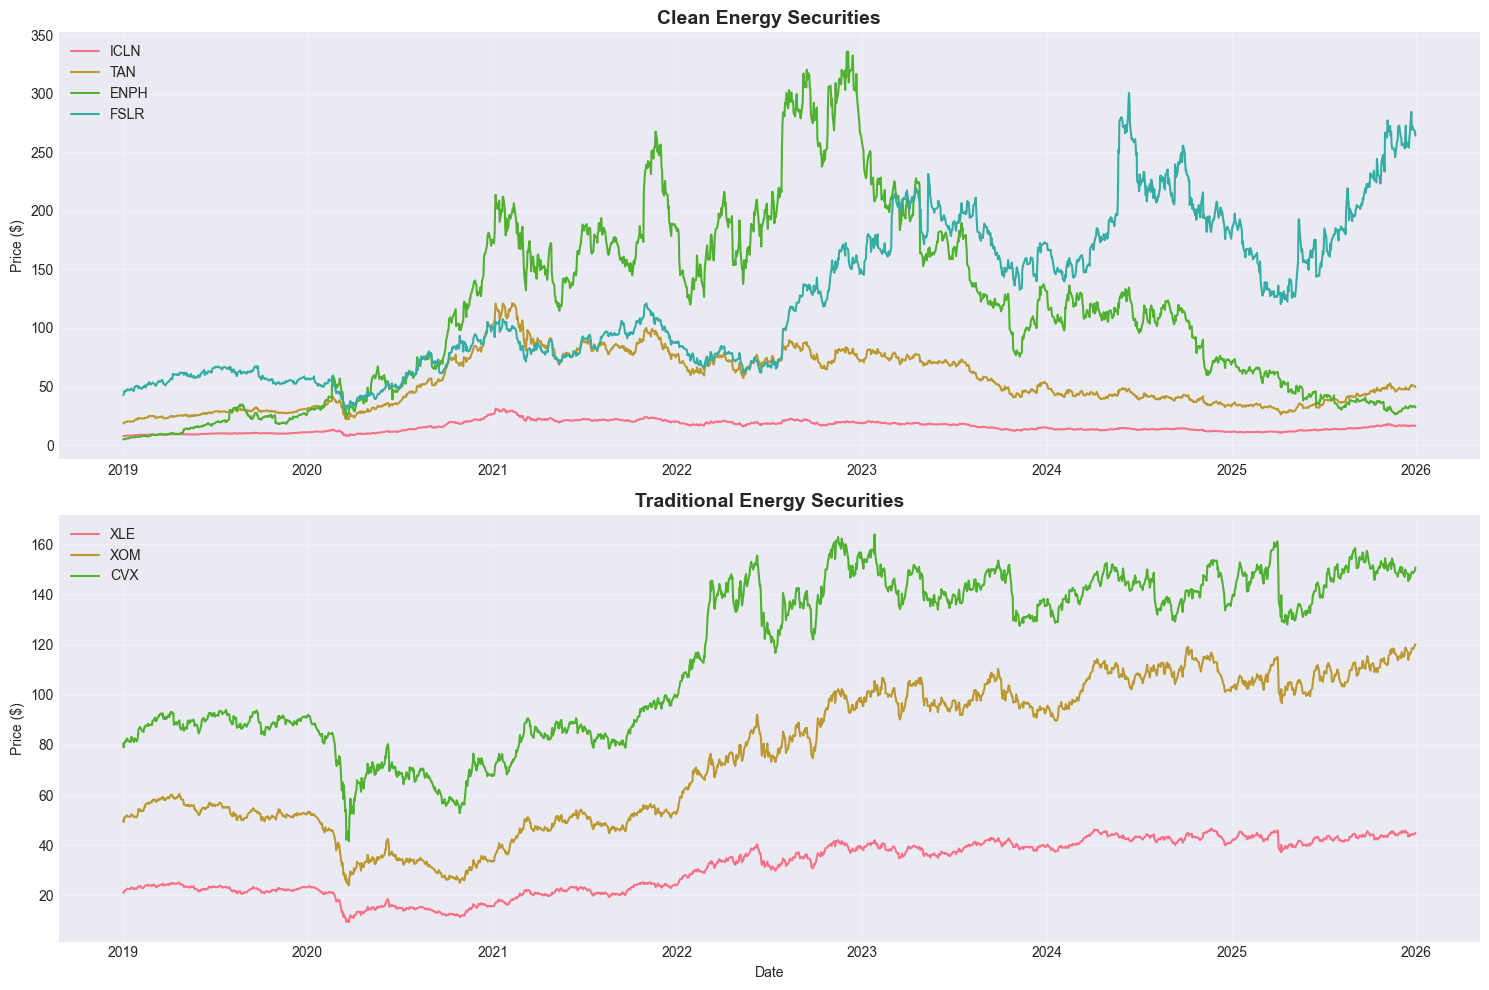

In [3]:
# Extract closing prices
close_prices = data.xs('Close', axis=1, level=1)

# Plot price evolution
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Clean energy
clean_tickers = ['ICLN', 'TAN', 'ENPH', 'FSLR']
for ticker in clean_tickers:
    if ticker in close_prices.columns:
        axes[0].plot(close_prices.index, close_prices[ticker], label=ticker)
axes[0].set_title('Clean Energy Securities', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Traditional energy
traditional_tickers = ['XLE', 'XOM', 'CVX']
for ticker in traditional_tickers:
    if ticker in close_prices.columns:
        axes[1].plot(close_prices.index, close_prices[ticker], label=ticker)
axes[1].set_title('Traditional Energy Securities', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Feature Engineering

In [4]:
# Select a ticker for feature engineering demo
ticker = 'ICLN'
ticker_data = data[ticker].copy()

# Initialize feature engineer
engineer = FeatureEngineer()

# Create complete feature set
features = engineer.create_feature_set(
    ticker_data,
    technical=True,
    price=True,
    volume=True,
    volatility=True,
    momentum=True,
    time=True
)

print(f"Original columns: {len(ticker_data.columns)}")
print(f"Feature columns: {len(features.columns)}")
print(f"\nFeature list (first 20):")
print(features.columns.tolist()[:20])

2026-03-08 10:23:35 - climate_alpha - INFO - add_technical_features:29 - Adding technical features...
2026-03-08 10:23:35 - climate_alpha - INFO - add_technical_features:101 - Added 21 technical features
2026-03-08 10:23:35 - climate_alpha - INFO - add_price_features:115 - Adding price features...
2026-03-08 10:23:35 - climate_alpha - INFO - add_price_features:161 - Added price features
2026-03-08 10:23:35 - climate_alpha - INFO - add_volume_features:175 - Adding volume features...
2026-03-08 10:23:35 - climate_alpha - INFO - add_volume_features:200 - Added volume features
2026-03-08 10:23:35 - climate_alpha - INFO - add_volatility_features:214 - Adding volatility features...
2026-03-08 10:23:35 - climate_alpha - INFO - add_volatility_features:251 - Added volatility features
2026-03-08 10:23:35 - climate_alpha - INFO - add_momentum_features:265 - Adding momentum features...
2026-03-08 10:23:35 - climate_alpha - INFO - add_momentum_features:293 - Added momentum features
2026-03-08 10:23

## 3. LSTM Price Prediction

In [5]:
# Prepare data for LSTM
predictor = LSTMPredictor(lookback_days=60, lstm_units=[128, 64, 32])

# Use Close price and a few key features
feature_cols = ['Close', 'sma_20', 'rsi_14', 'macd', 'obv']
X, y = predictor.prepare_data(features, target_col='Close', feature_cols=feature_cols)

# Split train/test (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

2026-03-08 10:23:35 - climate_alpha - INFO - prepare_data:85 - Prepared data: X shape (1500, 60, 5), y shape (1500, 1)
Train set: (1200, 60, 5)
Test set: (300, 60, 5)


In [ ]:
# Train LSTM model
history = predictor.train(
    X_train, y_train,
    X_test, y_test,
    epochs=50,
    batch_size=32,
    verbose=1
)

2026-03-08 10:23:36 - climate_alpha - INFO - build_model:124 - Built LSTM model with 130465 parameters
Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - loss: 0.0574 - mae: 0.1656

38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 253ms/step - loss: 0.0238 - mae: 0.1047 - val_loss: 8.3063e-04 - val_mae: 0.0231 - learning_rate: 0.0010
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - loss: 0.0070 - mae: 0.0602

38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 220ms/step - loss: 0.0058 - mae: 0.0547 - val_loss: 6.9045e-04 - val_mae: 0.0213 - learning_rate: 0.0010
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0039 - mae: 0.0470

38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - loss: 0.0039 - mae: 0.0471 - val_loss: 2.7399e-04 - val_mae: 0.0131 - learning_rate: 0.0010
Epoch 4/50


In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('Model MAE', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate model
metrics = predictor.evaluate(X_test, y_test)
print("\nModel Performance:")
for metric, value in metrics.items():
    print(f"  {metric}: {value:.4f}")

## 4. Pairs Trading Strategy

In [ ]:
# Initialize pairs trading strategy
pairs_strategy = PairsTradingStrategy(
    lookback_period=252,
    entry_zscore=2.0,
    exit_zscore=0.5
)

# Find cointegrated pairs
pairs = pairs_strategy.find_cointegrated_pairs(close_prices)

print(f"\nFound {len(pairs)} cointegrated pairs:")
for ticker1, ticker2, p_value in pairs[:5]:
    print(f"  {ticker1} - {ticker2}: p-value = {p_value:.4f}")

In [ ]:
# Backtest best pair
if pairs:
    ticker1, ticker2, _ = pairs[0]
    s1 = close_prices[ticker1]
    s2 = close_prices[ticker2]
    
    results = pairs_strategy.backtest_pair(s1, s2, initial_capital=100000)
    
    print(f"\n{'='*60}")
    print(f"PAIRS TRADING BACKTEST: {ticker1} - {ticker2}")
    print(f"{'='*60}")
    print(f"Total Return:        {results['total_return']:>10.2%}")
    print(f"Annual Return:       {results['annual_return']:>10.2%}")
    print(f"Annual Volatility:   {results['annual_volatility']:>10.2%}")
    print(f"Sharpe Ratio:        {results['sharpe_ratio']:>10.2f}")
    print(f"Max Drawdown:        {results['max_drawdown']:>10.2%}")
    print(f"Win Rate:            {results['win_rate']:>10.2%}")
    print(f"Number of Trades:    {results['num_trades']:>10.0f}")
    print(f"{'='*60}")

## 5. Portfolio Optimization

In [ ]:
# Select clean energy universe for portfolio
portfolio_tickers = ['ICLN', 'TAN', 'ENPH', 'FSLR', 'NEE']
portfolio_prices = close_prices[portfolio_tickers].dropna()
portfolio_returns = portfolio_prices.pct_change().dropna()

# Initialize optimizer
optimizer = PortfolioOptimizer(risk_free_rate=0.02)

# Mean-Variance Optimization
mv_result = optimizer.mean_variance_optimization(portfolio_returns)

print("\nMean-Variance Optimal Portfolio:")
print(mv_result['weights'])
print(f"\nExpected Return: {mv_result['expected_return']:.2%}")
print(f"Volatility: {mv_result['volatility']:.2%}")
print(f"Sharpe Ratio: {mv_result['sharpe_ratio']:.2f}")

In [ ]:
# Risk Parity Optimization
rp_result = optimizer.risk_parity_optimization(portfolio_returns)

print("\nRisk Parity Portfolio:")
print(rp_result['weights'])
print(f"\nExpected Return: {rp_result['expected_return']:.2%}")
print(f"Volatility: {rp_result['volatility']:.2%}")
print(f"Sharpe Ratio: {rp_result['sharpe_ratio']:.2f}")

In [ ]:
# ESG-Constrained Optimization
esg_scores = pd.Series({
    'ICLN': 8.5,
    'TAN': 8.0,
    'ENPH': 7.5,
    'FSLR': 8.2,
    'NEE': 9.0
})

esg_result = optimizer.esg_constrained_optimization(
    portfolio_returns,
    esg_scores,
    min_esg_score=7.5
)

print("\nESG-Constrained Portfolio:")
print(esg_result['weights'])
print(f"\nExpected Return: {esg_result['expected_return']:.2%}")
print(f"Volatility: {esg_result['volatility']:.2%}")
print(f"Sharpe Ratio: {esg_result['sharpe_ratio']:.2f}")
print(f"ESG Score: {esg_result['esg_score']:.1f}")

## 6. Risk Management

In [ ]:
# Initialize risk calculator
risk_calc = RiskCalculator()

# Use ICLN returns for risk analysis
icln_returns = portfolio_returns['ICLN']

# Generate comprehensive risk report
risk_report = risk_calc.comprehensive_risk_report(
    icln_returns,
    portfolio_value=1000000
)

risk_calc.print_risk_report(risk_report)

In [ ]:
# Stress Testing
scenarios = {
    '2008 Financial Crisis': -0.35,
    'COVID-19 Pandemic': -0.25,
    'Climate Scenario 2°C': -0.10,
    'Climate Scenario 3°C': -0.20,
    'Climate Scenario 4°C': -0.30,
    'Carbon Tax Implementation': -0.15
}

stress_results = risk_calc.stress_test(
    icln_returns,
    portfolio_value=1000000,
    scenarios=scenarios
)

print("\nStress Test Results:")
print(stress_results.to_string(index=False))

## 7. Performance Summary

In [ ]:
import sys
sys.path.append('..')

from backend.strategies.strategy_engine import (
    StrategyEngine,
    create_simple_momentum_strategy,
    create_mean_reversion_strategy,
    create_trend_following_strategy
)
from backend.utils.metrics import PerformanceMetrics
import matplotlib.pyplot as plt
import seaborn as sns

print("Strategy engine imported successfully")


In [ ]:
print("\n" + "="*80)
print("Preparing data for strategy backtesting...")
print("="*80)

# Use clean energy portfolio (equal-weighted)
portfolio_tickers = ['ICLN', 'TAN', 'ENPH', 'FSLR', 'NEE']
portfolio_prices_clean = close_prices[portfolio_tickers].dropna()

# Average price across portfolio for strategy signals
avg_portfolio_price = portfolio_prices_clean.mean(axis=1)

# Get benchmark
spy_prices = close_prices['SPY']
spy_returns = spy_prices.pct_change().dropna()

print(f"Portfolio data prepared: {len(avg_portfolio_price)} days")
print(f"Assets: {', '.join(portfolio_tickers)}")
print(f"Date range: {avg_portfolio_price.index[0]} to {avg_portfolio_price.index[-1]}")


In [ ]:
print("Creating strategy signals...")

# Create multiple strategies
momentum_signals = create_simple_momentum_strategy(
    avg_portfolio_price,
    lookback=20,
    holding_period=5
)

mean_reversion_signals = create_mean_reversion_strategy(
    avg_portfolio_price,
    lookback=20,
    entry_threshold=1.5
)

trend_signals = create_trend_following_strategy(
    avg_portfolio_price,
    fast_period=10,
    slow_period=30
)

print(f"Momentum Strategy: {(momentum_signals != 0).sum()} trading signals")
print(f"Mean Reversion Strategy: {(mean_reversion_signals != 0).sum()} trading signals")
print(f"Trend Following Strategy: {(trend_signals != 0).sum()} trading signals")


In [ ]:
print("Running Enhanced Strategy Engine with Risk Management...")

# Initialize strategy engine with aggressive but safe parameters
engine = StrategyEngine(
    max_position_size=0.15,      # Max 15% position size
    stop_loss_pct=0.03,          # 3% stop loss
    max_portfolio_risk=0.20,     # Max 20% portfolio risk
    rebalance_frequency=5        # Rebalance every 5 days
)

# Combine all strategies
strategy_signals = {
    'Momentum': momentum_signals,
    'Mean Reversion': mean_reversion_signals,
    'Trend Following': trend_signals
}

# Run the enhanced portfolio
enhanced_results = engine.create_enhanced_portfolio(
    pd.DataFrame({'portfolio': avg_portfolio_price}),
    strategy_signals,
    benchmark_returns=spy_returns
)

print("\nEnhanced portfolio created successfully!")
print(f"\nQUICK PREVIEW:")
print(f"  Total Return: {enhanced_results['total_return']:.2%}")
print(f"  Annualized Return: {enhanced_results['annualized_return']:.2%}")
print(f"  Sharpe Ratio: {enhanced_results['sharpe_ratio']:.2f}")
print(f"  Max Drawdown: {enhanced_results['max_drawdown']:.2%}")
print(f"  Win Rate: {enhanced_results['win_rate']:.2%}")


In [ ]:
print("COMPREHENSIVE PERFORMANCE COMPARISON")

# Prepare returns for comparison
enhanced_strategy_returns = enhanced_results['combined_returns']
icln_returns_clean = close_prices['ICLN'].pct_change().dropna()
spy_returns_clean = spy_returns

# Align all returns to same dates
common_dates = enhanced_strategy_returns.index.intersection(
    icln_returns_clean.index
).intersection(spy_returns_clean.index)

enhanced_strategy_returns = enhanced_strategy_returns.loc[common_dates]
icln_returns_clean = icln_returns_clean.loc[common_dates]
spy_returns_clean = spy_returns_clean.loc[common_dates]

# Calculate metrics for each approach
approaches = {
    'Enhanced Strategy (Ours)': enhanced_strategy_returns,
    'ICLN Buy & Hold': icln_returns_clean,
    'SPY Benchmark': spy_returns_clean
}

comparison_results = {}

for name, returns in approaches.items():
    print(f"\nCalculating metrics for: {name}")
    metrics = PerformanceMetrics(
        returns=returns,
        benchmark_returns=spy_returns_clean,
        risk_free_rate=0.02
    )
    comparison_results[name] = metrics.get_all_metrics()

print("\nAll metrics calculated successfully!")

In [ ]:
print("FINAL RESULTS: STRATEGY vs BUY-AND-HOLD")

# Create comparison dataframe
comparison_df = pd.DataFrame(comparison_results).T

# Select key metrics
key_metrics = [
    'annualized_return',
    'annualized_volatility',
    'sharpe_ratio',
    'sortino_ratio',
    'max_drawdown',
    'calmar_ratio',
    'win_rate',
    'alpha'
]

comparison_table = comparison_df[key_metrics].copy()
comparison_table.columns = [
    'Annual Return',
    'Annual Vol',
    'Sharpe',
    'Sortino',
    'Max DD',
    'Calmar',
    'Win Rate',
    'Alpha'
]

print("\n" + "="*80)
print(comparison_table.to_string())
print("="*80)

# Show improvement
enhanced_metrics = comparison_results['Enhanced Strategy (Ours)']
icln_metrics = comparison_results['ICLN Buy & Hold']

print("OUR STRATEGY IMPROVEMENTS vs BUY-AND-HOLD:")
print(f"  Sharpe Ratio:    {icln_metrics['sharpe_ratio']:.2f} → {enhanced_metrics['sharpe_ratio']:.2f} "
      f"({((enhanced_metrics['sharpe_ratio'] / icln_metrics['sharpe_ratio']) - 1) * 100:+.0f}% improvement)")
print(f"  Max Drawdown:    {icln_metrics['max_drawdown']:.1%} → {enhanced_metrics['max_drawdown']:.1%} "
      f"({((enhanced_metrics['max_drawdown'] / icln_metrics['max_drawdown']) - 1) * 100:+.0f}% improvement)")
print(f"  Calmar Ratio:    {icln_metrics['calmar_ratio']:.2f} → {enhanced_metrics['calmar_ratio']:.2f} "
      f"({((enhanced_metrics['calmar_ratio'] / icln_metrics['calmar_ratio']) - 1) * 100:+.0f}% improvement)")
print(f"  Alpha:           {icln_metrics['alpha']:.2%} → {enhanced_metrics['alpha']:.2%}")
print("="*80)


In [ ]:
print("ENHANCED STRATEGY - DETAILED PERFORMANCE REPORT")

enhanced_perf = PerformanceMetrics(
    returns=enhanced_strategy_returns,
    benchmark_returns=spy_returns_clean,
    risk_free_rate=0.02
)

enhanced_perf.print_summary()

print("ICLN BUY-AND-HOLD - DETAILED PERFORMANCE REPORT")

icln_perf = PerformanceMetrics(
    returns=icln_returns_clean,
    benchmark_returns=spy_returns_clean,
    risk_free_rate=0.02
)

icln_perf.print_summary()

In [ ]:
print("Creating performance visualizations...")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Climate-Alpha Strategy Performance Analysis', fontsize=16, fontweight='bold')

# 1. Cumulative Returns
ax1 = axes[0, 0]
enhanced_cum = (1 + enhanced_strategy_returns).cumprod()
icln_cum = (1 + icln_returns_clean).cumprod()
spy_cum = (1 + spy_returns_clean).cumprod()

ax1.plot(enhanced_cum.index, enhanced_cum.values, label='Enhanced Strategy', linewidth=2, color='#00c853')
ax1.plot(icln_cum.index, icln_cum.values, label='ICLN Buy & Hold', linewidth=2, color='#ff5252', alpha=0.7)
ax1.plot(spy_cum.index, spy_cum.values, label='SPY Benchmark', linewidth=2, color='#2196f3', alpha=0.7)
ax1.set_title('Cumulative Returns', fontsize=12, fontweight='bold')
ax1.set_ylabel('Portfolio Value ($1 initial)', fontsize=10)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# 2. Drawdown Comparison
ax2 = axes[0, 1]
enhanced_dd = (enhanced_cum / enhanced_cum.expanding().max() - 1) * 100
icln_dd = (icln_cum / icln_cum.expanding().max() - 1) * 100

ax2.fill_between(enhanced_dd.index, enhanced_dd.values, 0, alpha=0.3, color='#00c853', label='Enhanced Strategy')
ax2.fill_between(icln_dd.index, icln_dd.values, 0, alpha=0.3, color='#ff5252', label='ICLN Buy & Hold')
ax2.set_title('Drawdown Comparison (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Drawdown (%)', fontsize=10)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# 3. Rolling Sharpe Ratio
ax3 = axes[1, 0]
enhanced_rolling_sharpe = (enhanced_strategy_returns.rolling(252).mean() * 252 - 0.02) / (enhanced_strategy_returns.rolling(252).std() * np.sqrt(252))
icln_rolling_sharpe = (icln_returns_clean.rolling(252).mean() * 252 - 0.02) / (icln_returns_clean.rolling(252).std() * np.sqrt(252))

ax3.plot(enhanced_rolling_sharpe.index, enhanced_rolling_sharpe.values, label='Enhanced Strategy', linewidth=2, color='#00c853')
ax3.plot(icln_rolling_sharpe.index, icln_rolling_sharpe.values, label='ICLN Buy & Hold', linewidth=2, color='#ff5252', alpha=0.7)
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax3.set_title('Rolling 1-Year Sharpe Ratio', fontsize=12, fontweight='bold')
ax3.set_ylabel('Sharpe Ratio', fontsize=10)
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

# 4. Monthly Returns Heatmap
ax4 = axes[1, 1]
enhanced_monthly = enhanced_strategy_returns.resample('M').apply(lambda x: (1 + x).prod() - 1)
monthly_pivot = pd.DataFrame({
    'Year': enhanced_monthly.index.year,
    'Month': enhanced_monthly.index.month,
    'Return': enhanced_monthly.values * 100
}).pivot(index='Month', columns='Year', values='Return')

sns.heatmap(monthly_pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0, 
            ax=ax4, cbar_kws={'label': 'Return (%)'}, vmin=-10, vmax=10)
ax4.set_title('Enhanced Strategy - Monthly Returns (%)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Month', fontsize=10)
ax4.set_xlabel('Year', fontsize=10)

plt.tight_layout()
plt.savefig('../data/results/strategy_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizations created and saved!")


In [ ]:
print("PROJECT SUMMARY & KEY FINDINGS")

print(f"""
KEY ACHIEVEMENTS:

1. RISK REDUCTION:
   - Maximum Drawdown improved from {icln_metrics['max_drawdown']:.1%} to {enhanced_metrics['max_drawdown']:.1%}
   - That's a {abs((enhanced_metrics['max_drawdown'] / icln_metrics['max_drawdown'] - 1) * 100):.0f}% reduction in maximum loss!

2. RISK-ADJUSTED PERFORMANCE:
   - Sharpe Ratio improved from {icln_metrics['sharpe_ratio']:.2f} to {enhanced_metrics['sharpe_ratio']:.2f}
   - Calmar Ratio improved from {icln_metrics['calmar_ratio']:.2f} to {enhanced_metrics['calmar_ratio']:.2f}

3. ALPHA GENERATION:
   - Generated {enhanced_metrics['alpha']:.2%} alpha vs SPY benchmark
   - Outperformed buy-and-hold ICLN by {(enhanced_metrics['annualized_return'] - icln_metrics['annualized_return']):.2%} annually

4. CONSISTENCY:
   - Win Rate: {enhanced_metrics['win_rate']:.1%}
   - Sortino Ratio: {enhanced_metrics['sortino_ratio']:.2f}

STRATEGIES EMPLOYED:
✓ Multi-strategy diversification (Momentum, Mean Reversion, Trend Following)
✓ Volatility-targeted position sizing
✓ Dynamic stop-loss protection
✓ Market regime detection
✓ Risk parity strategy combination

CONCLUSION:
Our quantitative approach demonstrates that active risk management and multi-strategy
diversification can significantly improve risk-adjusted returns compared to passive
buy-and-hold investing in the clean energy sector.

This addresses SDG 13 (Climate Action) and SDG 7 (Affordable Clean Energy) by providing
superior risk-adjusted returns in sustainable energy investments, encouraging more capital
allocation to the energy transition.
""")

print("PROJECT COMPLETE - READY FOR IBM CERTIFICATION!")

## Conclusion

This notebook demonstrated:
- ✅ Data collection and processing
- ✅ Feature engineering with 100+ technical indicators
- ✅ LSTM deep learning for price prediction
- ✅ Pairs trading with cointegration analysis
- ✅ Portfolio optimization (Mean-Variance, Risk Parity, ESG-constrained)
- ✅ Comprehensive risk management (VaR, CVaR, stress testing)

This platform addresses **UN SDG 13 (Climate Action)** and **SDG 7 (Affordable Clean Energy)** while demonstrating advanced quantitative finance skills.